In [1]:
# To import .py scripts as modules

import sys

sys.path.append("/Users/rohith_medam/Projects/Portfolio_Optimization/Scripts")
import userdf_fncs
import plots_fncs


In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [4]:
import yfinance as yf

In [5]:
import warnings

warnings.filterwarnings("ignore")

In [6]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 100)

In [7]:
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [8]:
config_params = {
    "Tickers": [
        # Technology
        "AAPL",
        "MSFT",
        "GOOGL",
        "AMZN",
        "TSLA",
        "NVDA",
        "META",
        # Financial
        "BRK-B",
        "JPM",
        "V",
        # Healthcare
        "JNJ",
        "LLY",
        "UNH",
        # Consumer Discretionary
        "PG",
        "WMT",
        "COST",
        # Energy
        "XOM",
        "CVX",
        # Benchmark
        "^GSPC",
    ],
    "risk_free_rate": 4.18,
    # "rebalance_frequency": "quarterly",
    # "transaction_cost": 0.0015,
    # "train_test_split": 0.8,
    # "validation_split": 0.2,
    # "radom_seed": 42,
}

In [9]:
raw_data = userdf_fncs.download_data(
    tickers=config_params["Tickers"],
    lookback_window=10,
)

raw_data


Tickers: AAPL, MSFT, GOOGL, AMZN, TSLA, NVDA, META, BRK-B, JPM, V, JNJ, LLY, UNH, PG, WMT, COST, XOM, CVX, ^GSPC



[*********************100%***********************]  19 of 19 completed


Ticker            TSLA                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2016-01-25   13.337333   13.571333   13.058667   13.092000  40480500   
2016-01-26   13.113333   13.188000   12.592000   12.904000  74463000   
2016-01-27   12.825333   12.884000   12.384667   12.538000  54258000   
2016-01-28   12.719333   12.752000   12.160667   12.646667  68892000   
2016-01-29   12.663333   12.916000   12.538667   12.746667  42784500   
...                ...         ...         ...         ...       ...   
2026-01-16  439.500000  447.250000  435.260010  437.500000  60220600   
2026-01-20  429.359985  430.730011  417.440002  419.250000  63187300   
2026-01-21  421.660004  438.200012  419.619995  431.440002  68124000   
2026-01-22  435.160004  449.500000  432.630005  449.359985  71546700   
2026-01-23  447.429993  452.429993  444.040009  449.059998  56636400   

Ticker               V                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2016-01-25   67.836527   67.976378   66.736374   66.885544   9126200   
2016-01-26   67.295770   67.379677   66.708403   67.016068   7500200   
2016-01-27   67.109313   67.575479   65.804046   66.111717   9020500   
2016-01-28   66.587190   66.988093   64.638618   64.638618  15295600   
2016-01-29   65.664180   69.458773   64.107186   69.449448  40427800   
...                ...         ...         ...         ...       ...   
2026-01-16  326.779999  329.250000  325.399994  328.299988   8341600   
2026-01-20  322.230011  328.320007  321.559998  325.820007   8279900   
2026-01-21  326.429993  328.670013  323.000000  325.279999   8974600   
2026-01-22  326.459991  328.390015  324.000000  326.359985   6938700   
2026-01-23  325.859985  327.799988  324.619995  326.179993   5665900   

Ticker            AAPL                                                 \
Price             Open        High         Low       Close     Volume   
Date                                                                    
2016-01-25   22.889607   22.891863   22.368775   22.420633  207178000   
2016-01-26   22.531112   22.745307   22.111740   22.544640  300308000   
2016-01-27   21.654030   21.787056   21.045263   21.063301  533478800   
2016-01-28   21.146735   21.311326   20.831078   21.214375  222715200   
2016-01-29   21.372208   21.947153   21.273001   21.947153  257666000   
...                ...         ...         ...         ...        ...   
2026-01-16  257.899994  258.899994  254.929993  255.529999   72142800   
2026-01-20  252.729996  254.789993  243.419998  246.699997   80267500   
2026-01-21  248.699997  251.559998  245.179993  247.649994   54641700   
2026-01-22  249.199997  251.000000  248.149994  248.350006   39708300   
2026-01-23  247.320007  249.410004  244.679993  248.039993   41625700   

Ticker             JNJ                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2016-01-25   73.323180   74.058536   72.807674   73.080589   9350200   
2016-01-26   73.732545   76.825577   73.641571   76.704285  17266600   
2016-01-27   76.181208   78.372109   76.181208   77.447235  19330500   
2016-01-28   77.704989   78.114363   77.212225   77.530624  12789500   
2016-01-29   78.000644   79.410706   77.803537   79.175697  15614600   
...                ...         ...         ...         ...       ...   
2026-01-16  219.039993  220.110001  218.139999  218.660004  10021500   
2026-01-20  217.089996  218.729996  214.500000  218.210007  14057100   
2026-01-21  211.000000  218.679993  210.500000  218.009995  14762900   
2026-01-22  218.770004  222.169998  218.100006  218.490005  13160000   
2026-01-23  219.800003 

In [10]:
# To process raw data and convert it to dataframes.

processed_data = userdf_fncs.process_raw_data(raw_data, config_params["Tickers"])

prices = processed_data["prices"]
volume = processed_data["volume"]
returns = processed_data["returns"]

Processed data:

Prices shape: (2515, 19)

Returns shape: (2514, 19)



In [11]:
# Data validation to check for missing values and outliers.

is_valid = userdf_fncs.data_validation(returns, prices)

No missing values in returns 

No missing values in prices 

No extreme returns found 



In [12]:
# Returns summary stats - annualized returns and volatility, Sharpe ratio, and total returns.

summary_stats = userdf_fncs.summary_stats(
    returns=returns,
    prices=prices,
    risk_free_rate=config_params["risk_free_rate"],
    lookback_window=10,
)

In [13]:
# Saves prices, returns, volumne, and summary stats dataframes to .csv and excel files.

userdf_fncs.data_write_csv(
    data_files=[prices, returns, volume, summary_stats],
    file_names=["prices.csv", "returns.csv", "volume.csv", "summary_stats.csv"],
    folder_name="Data",
    date_format="%Y-%m-%d",
)

The prices data has been saved to /Users/rohith_medam/Projects/Portfolio_Optimization/Data as prices.csv

The returns data has been saved to /Users/rohith_medam/Projects/Portfolio_Optimization/Data as returns.csv

The volume data has been saved to /Users/rohith_medam/Projects/Portfolio_Optimization/Data as volume.csv

The summary_stats data has been saved to /Users/rohith_medam/Projects/Portfolio_Optimization/Data as summary_stats.csv



In [14]:
# To combine all dataframes in to an excel file.

userdf_fncs.data_write_excel(
    worksheet_names=["Prices", "Returns", "Volume", "Summary_stats"],
    dataframes=[prices, returns, volume, summary_stats],
    folder_name="Data",
    file_name="data_excel.xlsx",
    date_format="YYYY-MM-DD",
)

The following data - ['Prices', 'Returns', 'Volume', 'Summary_stats'] has been combined and saved to /Users/rohith_medam/Projects/Portfolio_Optimization/Data as data_excel.xlsx



Correlation Analysis - 

Asset pairs with correlation greater than 0.7: 

stock 1 stock 2  correlation
    XOM     CVX     0.831860
   MSFT   ^GSPC     0.796712
      V   ^GSPC     0.756057
  BRK-B   ^GSPC     0.753786
   AAPL   ^GSPC     0.752493
  BRK-B     JPM     0.739667
  GOOGL   ^GSPC     0.719229
    JPM   ^GSPC     0.711103
   MSFT   GOOGL     0.700458

The average pairwise correlation of assets within the portfolio: 0.382 

Summary - Decent diversification with moderate correlation 



Correlation Heatmap - 



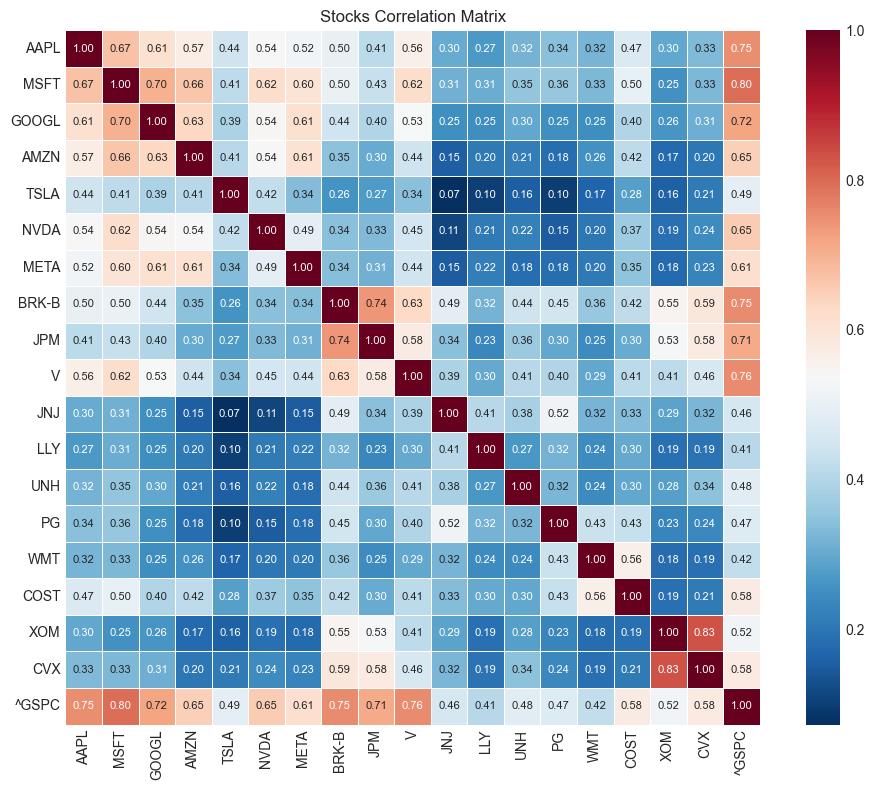

Correlation matrix image saved to /Users/rohith_medam/Projects/Portfolio_Optimization/Images


<Figure size 640x480 with 0 Axes>

In [15]:
# Generates a correlation heatmap and saves it to the specified folder.

corr_matrix = userdf_fncs.correlation_analysis(returns, correlation_thres=0.7)

print("\n")

plots_fncs.plot_correlation_heatmap(
    correlation_matrix=corr_matrix, folder_to_save="Images", file_name="corr_matrix.png"
)

Rolling volatility plot image saved to /Users/rohith_medam/Projects/Portfolio_Optimization/Images 



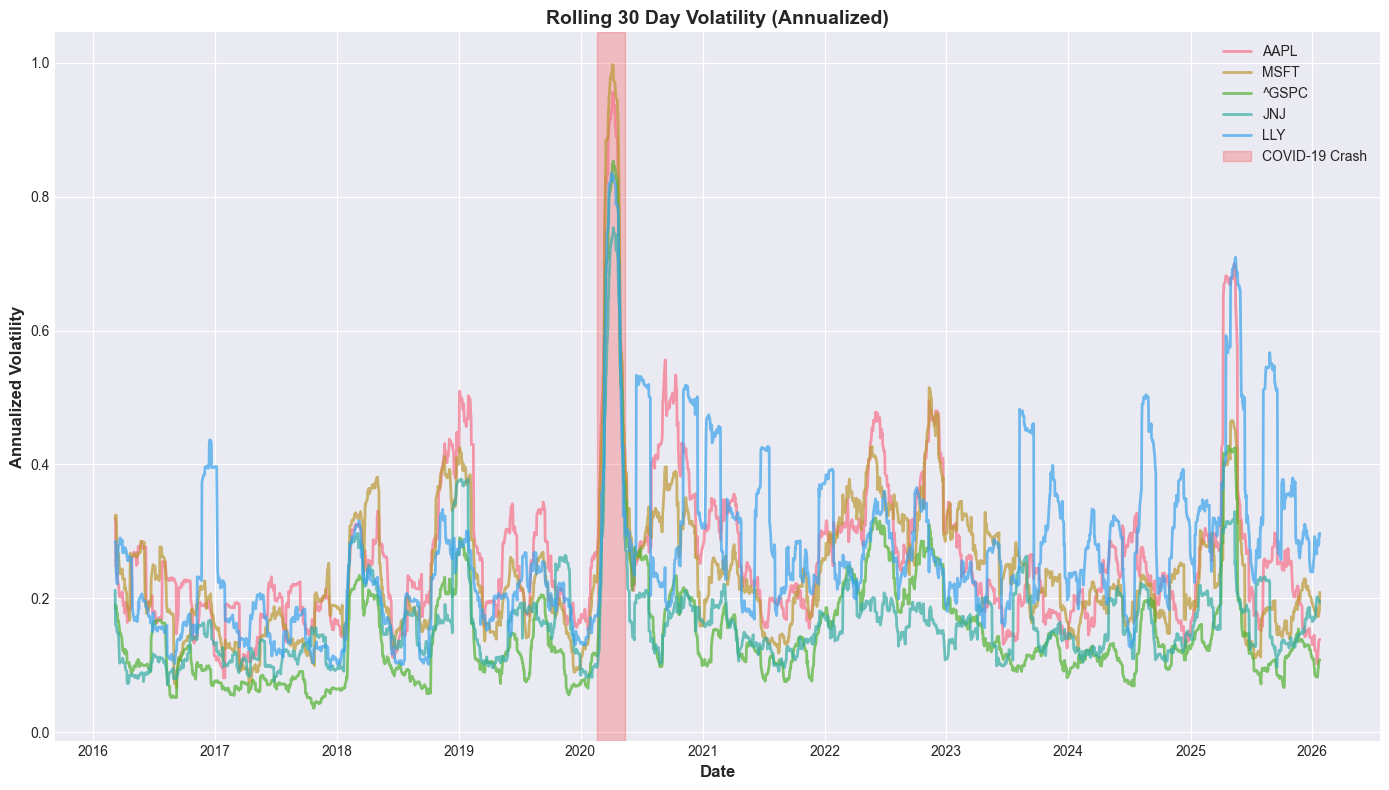

In [16]:
# Generates 30-day rolling volatility plot and saves it to the specified folder.

plots_fncs.plot_rolling_vol(
    returns=returns,
    rolling_window=30,
    stocks_list=["AAPL", "MSFT", "^GSPC", "JNJ", "LLY"],
    folder_to_save="Images",
    file_name="rolling_vol.png",
)